
# 01 Data Quality EDA — GA4 E-Commerce BigQuery Dataset

## Project Context

This notebook is the first technical step in the **E-Commerce Product Analytics & Experimentation Platform** project.

The goal is to understand the Google Analytics 4 BigQuery e-commerce demo dataset before building product KPIs, funnel analysis, retention cohorts, customer segments, purchase propensity models, and experimentation analysis.

## Notebook Goals

1. Understand dataset size, date range, users, sessions, and event volume.
2. Inspect key GA4 event names.
3. Validate purchase and revenue fields.
4. Explore device, traffic source, geo, and item-level fields.
5. Identify nulls, placeholders, and data quality issues.
6. Create clean notes for the next SQL analytics layer.



## 0. Setup

### Running this notebook locally in VS Code

Recommended setup:

```bash
python -m venv .venv
source .venv/bin/activate   # Mac/Linux
pip install -r requirements.txt
```

You also need Google Cloud authentication.

Option 1, easiest if Google Cloud SDK is installed:

```bash
gcloud auth application-default login
```

Option 2: use a service account JSON key and set:

```bash
export GOOGLE_APPLICATION_CREDENTIALS="/path/to/key.json"
```

Do **not** commit service account keys to GitHub.


In [1]:

# If needed, uncomment this line once in your environment:
# !pip install pandas numpy matplotlib google-cloud-bigquery db-dtypes pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Replace with your Google Cloud project ID.
# This is the project where you are running BigQuery jobs, not the public dataset project.
PROJECT_ID = "ecommerce-product-analytics"

client = bigquery.Client(project=PROJECT_ID)

EVENTS_TABLE = "`bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`"

print("BigQuery client ready.")

BigQuery client ready.



## Helper Function

This function runs SQL in BigQuery and returns a pandas DataFrame.

The `maximum_bytes_billed` setting is a safety guard so one accidental query does not scan too much data.


In [2]:

def query_to_df(sql: str, max_gb_billed: int = 5) -> pd.DataFrame:
    job_config = bigquery.QueryJobConfig(
        maximum_bytes_billed=max_gb_billed * 1024**3
    )
    return client.query(sql, job_config=job_config).to_dataframe()



# 1. Dataset Overview

We first check the date range, event volume, users, purchase events, and revenue coverage.


In [3]:

overview_sql = f'''
SELECT
  MIN(PARSE_DATE('%Y%m%d', event_date)) AS min_event_date,
  MAX(PARSE_DATE('%Y%m%d', event_date)) AS max_event_date,
  COUNT(*) AS total_events,
  COUNT(DISTINCT user_pseudo_id) AS total_users,
  COUNTIF(event_name = 'session_start') AS session_start_events,
  COUNTIF(event_name = 'view_item') AS view_item_events,
  COUNTIF(event_name = 'add_to_cart') AS add_to_cart_events,
  COUNTIF(event_name = 'begin_checkout') AS begin_checkout_events,
  COUNTIF(event_name = 'purchase') AS purchase_events,
  ROUND(SUM(COALESCE(ecommerce.purchase_revenue, 0)), 2) AS total_purchase_revenue
FROM {EVENTS_TABLE}
'''

overview_df = query_to_df(overview_sql)
overview_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,min_event_date,max_event_date,total_events,total_users,session_start_events,view_item_events,add_to_cart_events,begin_checkout_events,purchase_events,total_purchase_revenue
0,2020-11-01,2021-01-31,4295584,270154,354970,386068,58543,38757,5692,362165.0



## Initial Interpretation

After running the cell above, write 2–4 bullet points:

- What is the date range?
- How many users and events are available?
- Are purchase events relatively rare compared with browsing events?
- Is revenue populated for purchase events?



# 2. Event Name Distribution

This tells us which GA4 events are available and which ones are most important for product analytics.


In [4]:

event_distribution_sql = f'''
SELECT
  event_name,
  COUNT(*) AS event_count,
  COUNT(DISTINCT user_pseudo_id) AS unique_users,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 2) AS pct_of_all_events
FROM {EVENTS_TABLE}
GROUP BY event_name
ORDER BY event_count DESC
'''

event_dist_df = query_to_df(event_distribution_sql)
event_dist_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_name,event_count,unique_users,pct_of_all_events
0,page_view,1350428,269792,31.44
1,user_engagement,1058721,213004,24.65
2,scroll,493072,138098,11.48
3,view_item,386068,61252,8.99
4,session_start,354970,267116,8.26
5,first_visit,257462,257314,5.99
6,view_promotion,190104,102443,4.43
7,add_to_cart,58543,12545,1.36
8,begin_checkout,38757,9715,0.90
9,select_item,31007,13180,0.72


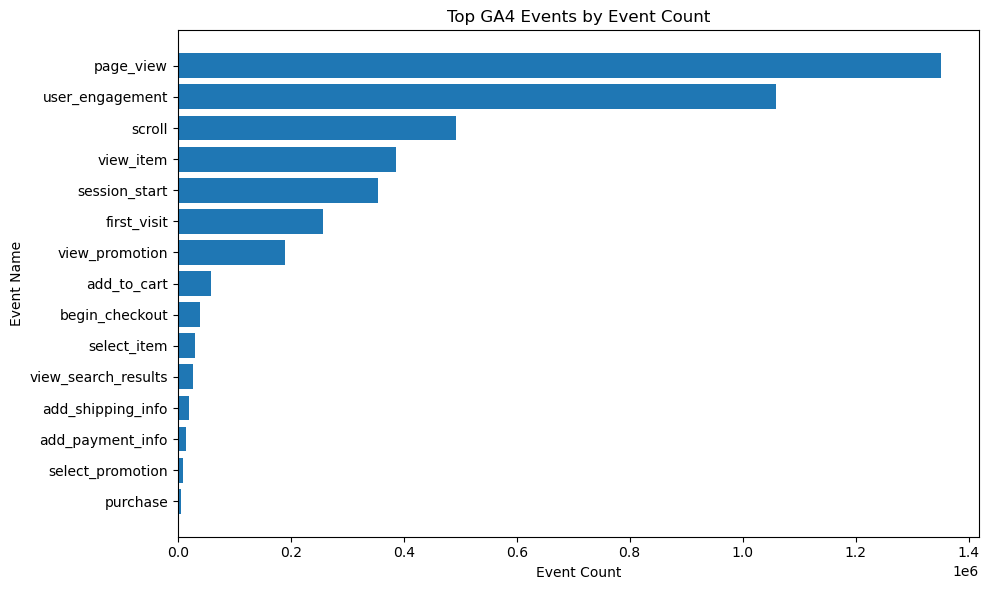

In [6]:

top_events = event_dist_df.head(15).sort_values("event_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_events["event_name"], top_events["event_count"])
plt.title("Top GA4 Events by Event Count")
plt.xlabel("Event Count")
plt.ylabel("Event Name")
plt.tight_layout()
plt.show()



## Event Distribution Notes

Write notes here:

- Which events dominate the dataset?
- Are the important funnel events present?
- Are there any unexpected events worth investigating?



# 3. Daily Event, User, and Revenue Trends

This helps identify seasonality, missing dates, spikes, or abnormal revenue days.


In [7]:

daily_trends_sql = f'''
SELECT
  PARSE_DATE('%Y%m%d', event_date) AS event_day,
  COUNT(*) AS total_events,
  COUNT(DISTINCT user_pseudo_id) AS active_users,
  COUNTIF(event_name = 'session_start') AS sessions,
  COUNTIF(event_name = 'purchase') AS purchases,
  ROUND(SUM(COALESCE(ecommerce.purchase_revenue, 0)), 2) AS revenue
FROM {EVENTS_TABLE}
GROUP BY event_day
ORDER BY event_day
'''

daily_df = query_to_df(daily_trends_sql)
daily_df.head()


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_day,total_events,active_users,sessions,purchases,revenue
0,2020-11-01,31272,2365,2594,14,773.0
1,2020-11-02,48388,3262,3682,49,4789.0
2,2020-11-03,61672,4648,5285,49,3313.0
3,2020-11-04,51866,3734,4281,46,2197.0
4,2020-11-05,51952,3272,3795,26,1792.0


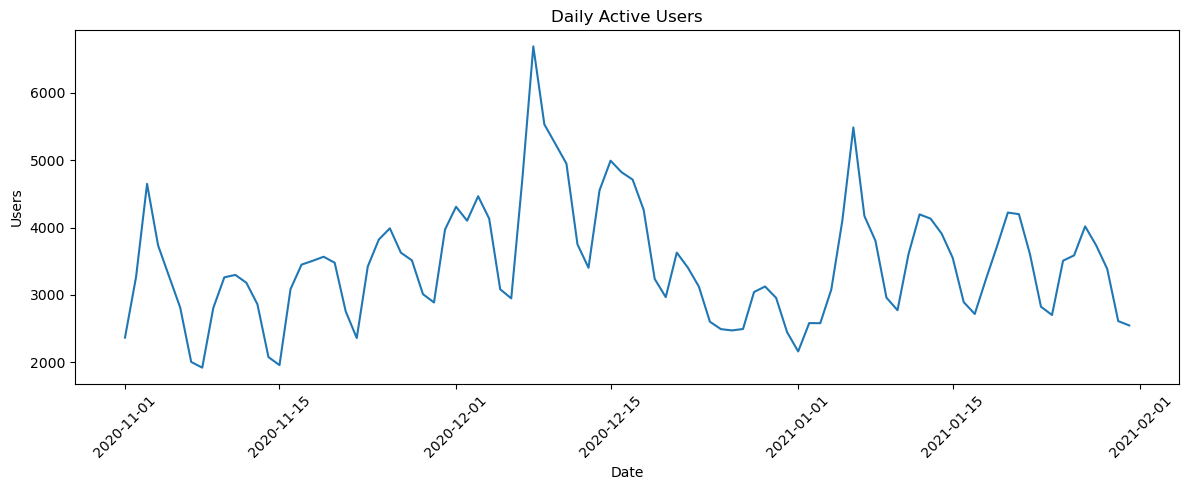

In [8]:

plt.figure(figsize=(12, 5))
plt.plot(daily_df["event_day"], daily_df["active_users"])
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


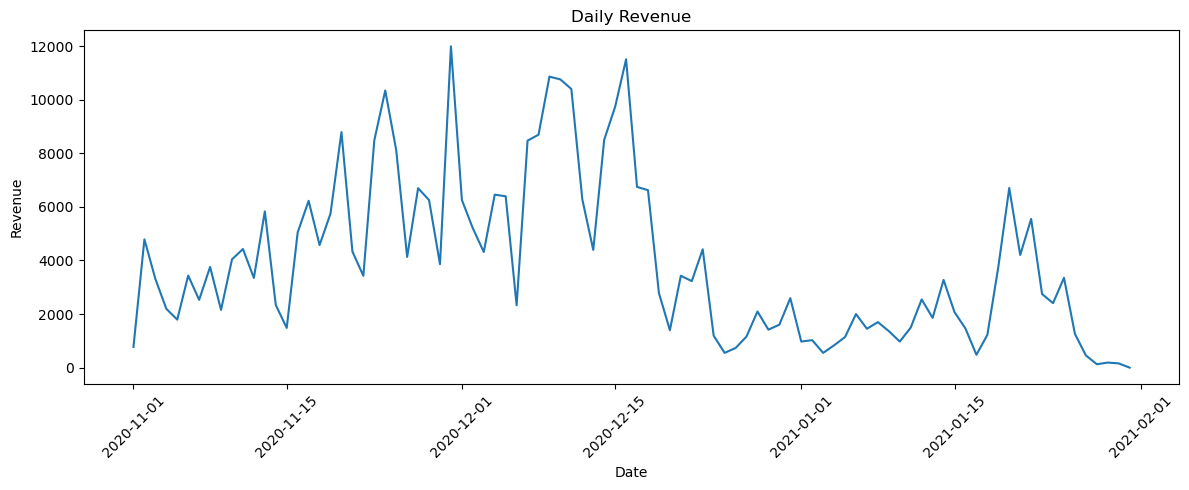

In [9]:

plt.figure(figsize=(12, 5))
plt.plot(daily_df["event_day"], daily_df["revenue"])
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Daily Trend Notes

Write notes here:

- Are there missing dates?
- Do revenue and purchase activity appear stable?
- Are there unusual spikes or dips?
- Is the date range long enough for cohort or retention analysis?



# 4. User and Session Coverage

GA4 stores session ID inside `event_params`, so we extract `ga_session_id`.

This helps us understand whether the data can support session-level funnel analysis.


In [10]:

session_coverage_sql = f'''
WITH events AS (
  SELECT
    event_date,
    event_name,
    user_pseudo_id,
    (
      SELECT value.int_value
      FROM UNNEST(event_params)
      WHERE key = 'ga_session_id'
    ) AS ga_session_id
  FROM {EVENTS_TABLE}
)

SELECT
  COUNT(*) AS total_events,
  COUNTIF(user_pseudo_id IS NULL) AS events_missing_user_id,
  COUNTIF(ga_session_id IS NULL) AS events_missing_session_id,
  COUNT(DISTINCT user_pseudo_id) AS unique_users,
  COUNT(DISTINCT CONCAT(user_pseudo_id, '-', CAST(ga_session_id AS STRING))) AS unique_user_sessions
FROM events
'''

session_coverage_df = query_to_df(session_coverage_sql)
session_coverage_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_events,events_missing_user_id,events_missing_session_id,unique_users,unique_user_sessions
0,4295584,0,0,270154,360129



## Session Coverage Notes

Write notes here:

- Is `ga_session_id` well populated?
- Can we create session-level funnel analysis?
- Do we need to handle missing session IDs?



# 5. Device, Traffic Source, and Geo Overview

This helps identify useful dimensions for dashboard filters and funnel breakdowns.


In [11]:

device_source_geo_sql = f'''
SELECT
  COALESCE(device.category, 'unknown') AS device_category,
  COALESCE(traffic_source.source, 'unknown') AS traffic_source,
  COALESCE(traffic_source.medium, 'unknown') AS traffic_medium,
  COALESCE(geo.country, 'unknown') AS country,
  COUNT(*) AS total_events,
  COUNT(DISTINCT user_pseudo_id) AS unique_users,
  COUNTIF(event_name = 'purchase') AS purchases,
  ROUND(SUM(COALESCE(ecommerce.purchase_revenue, 0)), 2) AS revenue
FROM {EVENTS_TABLE}
GROUP BY
  device_category,
  traffic_source,
  traffic_medium,
  country
ORDER BY total_events DESC
LIMIT 100
'''

device_source_geo_df = query_to_df(device_source_geo_sql)
device_source_geo_df.head(20)


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,device_category,traffic_source,traffic_medium,country,total_events,unique_users,purchases,revenue
0,desktop,google,organic,United States,344370,26491,338,24336.0
1,desktop,(direct),(none),United States,255615,19559,320,18191.0
2,mobile,google,organic,United States,240041,18166,282,19437.0
3,mobile,(direct),(none),United States,171546,13378,220,14718.0
4,desktop,<Other>,<Other>,United States,151281,12933,148,9253.0
5,desktop,<Other>,referral,United States,111173,8461,165,13088.0
6,mobile,<Other>,<Other>,United States,102664,8882,95,5712.0
7,desktop,shop.googlemerchandisestore.com,referral,United States,90262,6696,143,10332.0
8,desktop,(data deleted),(data deleted),United States,81864,4697,217,13064.0
9,mobile,<Other>,referral,United States,71106,5829,107,5198.0


In [12]:

device_summary = (
    device_source_geo_df
    .groupby("device_category", as_index=False)
    .agg(
        total_events=("total_events", "sum"),
        unique_users=("unique_users", "sum"),
        purchases=("purchases", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("total_events", ascending=False)
)

device_summary


,device_category,total_events,unique_users,purchases,revenue
0,desktop,1864343,144499,2356,157197.0
1,mobile,1175857,92066,1596,100632.0
2,tablet,28341,2266,19,870.0


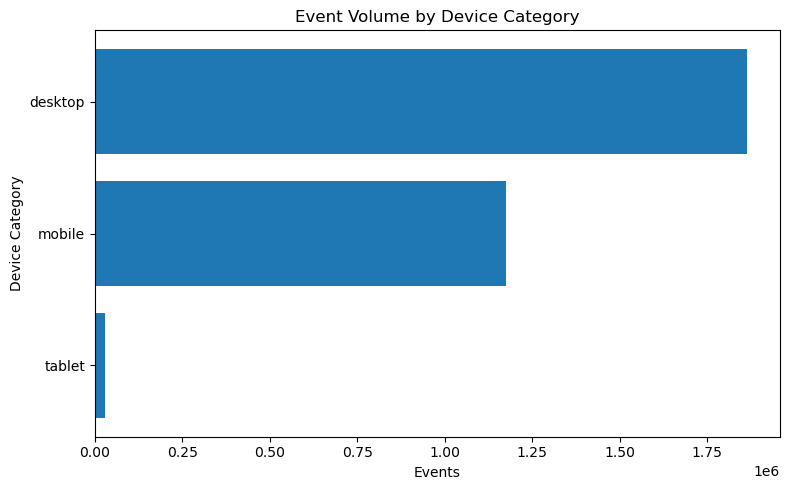

In [13]:

plot_df = device_summary.sort_values("total_events", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["device_category"], plot_df["total_events"])
plt.title("Event Volume by Device Category")
plt.xlabel("Events")
plt.ylabel("Device Category")
plt.tight_layout()
plt.show()



## Device and Source Notes

Write notes here:

- Which devices dominate event volume?
- Which traffic sources appear most common?
- Are there meaningful dimensions for funnel comparison?



# 6. Purchase Event Validation

Before using revenue in KPIs, we need to validate purchase events, transaction IDs, revenue, and item quantities.


In [14]:

purchase_validation_sql = f'''
SELECT
  COUNT(*) AS purchase_events,
  COUNT(DISTINCT ecommerce.transaction_id) AS unique_transactions,
  COUNTIF(ecommerce.transaction_id IS NULL OR ecommerce.transaction_id = '(not set)') AS missing_or_placeholder_transaction_id,
  COUNTIF(ecommerce.purchase_revenue IS NULL) AS missing_purchase_revenue,
  COUNTIF(ecommerce.purchase_revenue = 0) AS zero_purchase_revenue,
  COUNTIF(ecommerce.purchase_revenue < 0) AS negative_purchase_revenue,
  ROUND(SUM(COALESCE(ecommerce.purchase_revenue, 0)), 2) AS total_revenue,
  ROUND(AVG(ecommerce.purchase_revenue), 2) AS avg_purchase_revenue,
  ROUND(MIN(ecommerce.purchase_revenue), 2) AS min_purchase_revenue,
  ROUND(MAX(ecommerce.purchase_revenue), 2) AS max_purchase_revenue,
  SUM(ecommerce.total_item_quantity) AS total_item_quantity
FROM {EVENTS_TABLE}
WHERE event_name = 'purchase'
'''

purchase_validation_df = query_to_df(purchase_validation_sql)
purchase_validation_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,purchase_events,unique_transactions,missing_or_placeholder_transaction_id,missing_purchase_revenue,zero_purchase_revenue,negative_purchase_revenue,total_revenue,avg_purchase_revenue,min_purchase_revenue,max_purchase_revenue,total_item_quantity
0,5692,4452,906,450,0,0,362165.0,69.09,1.0,1530.0,22720


In [15]:

purchase_sample_sql = f'''
SELECT
  PARSE_DATE('%Y%m%d', event_date) AS event_day,
  TIMESTAMP_MICROS(event_timestamp) AS event_ts,
  user_pseudo_id,
  ecommerce.transaction_id,
  ecommerce.purchase_revenue,
  ecommerce.total_item_quantity,
  ecommerce.unique_items
FROM {EVENTS_TABLE}
WHERE event_name = 'purchase'
ORDER BY event_timestamp
LIMIT 50
'''

purchase_sample_df = query_to_df(purchase_sample_sql)
purchase_sample_df.head()


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_day,event_ts,user_pseudo_id,transaction_id,purchase_revenue,total_item_quantity,unique_items
0,2020-11-01,2020-11-01 00:27:14.469608+00:00,36638696.4029295753,None,34.0,2,2
1,2020-11-01,2020-11-01 01:44:44.942033+00:00,2422026.0165722609,None,72.0,3,2
2,2020-11-01,2020-11-01 04:11:11.477055+00:00,1494018.5183133777,None,25.0,1,1
3,2020-11-01,2020-11-01 06:17:40.454067+00:00,3297046.6509553424,None,87.0,4,4
4,2020-11-01,2020-11-01 09:53:30.531712+00:00,6828468.1695203512,None,46.0,8,4



## Purchase Validation Notes

Write notes here:

- Is transaction ID reliable?
- Are revenue values mostly populated?
- Are there zero or negative revenue cases?
- What assumptions will we use for revenue KPIs?



# 7. Item-Level Data Exploration

GA4 stores product data in a repeated `items` array. We use `UNNEST(items)` to analyze products and categories.


In [16]:

item_overview_sql = f'''
SELECT
  COUNT(*) AS item_rows,
  COUNT(DISTINCT item.item_id) AS unique_item_ids,
  COUNT(DISTINCT item.item_name) AS unique_item_names,
  COUNT(DISTINCT item.item_category) AS unique_item_categories,
  COUNTIF(item.item_id IS NULL OR item.item_id = '(not set)') AS missing_or_placeholder_item_id,
  COUNTIF(item.item_name IS NULL OR item.item_name = '(not set)') AS missing_or_placeholder_item_name,
  COUNTIF(item.item_category IS NULL OR item.item_category = '(not set)') AS missing_or_placeholder_item_category,
  COUNTIF(item.price IS NULL) AS missing_price,
  COUNTIF(item.quantity IS NULL) AS missing_quantity
FROM {EVENTS_TABLE},
UNNEST(items) AS item
'''

item_overview_df = query_to_df(item_overview_sql)
item_overview_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,item_rows,unique_item_ids,unique_item_names,unique_item_categories,missing_or_placeholder_item_id,missing_or_placeholder_item_name,missing_or_placeholder_item_category,missing_price,missing_quantity
0,3982732,1394,431,82,130641,148458,148459,148459,3832428


In [17]:

category_performance_sql = f'''
SELECT
  COALESCE(item.item_category, 'unknown') AS item_category,
  COUNTIF(event_name = 'view_item') AS item_views,
  COUNTIF(event_name = 'add_to_cart') AS add_to_carts,
  COUNTIF(event_name = 'purchase') AS purchases,
  ROUND(SUM(CASE WHEN event_name = 'purchase' THEN COALESCE(item.price, 0) * COALESCE(item.quantity, 0) ELSE 0 END), 2) AS estimated_item_revenue,
  SAFE_DIVIDE(COUNTIF(event_name = 'add_to_cart'), COUNTIF(event_name = 'view_item')) AS view_to_cart_rate,
  SAFE_DIVIDE(COUNTIF(event_name = 'purchase'), COUNTIF(event_name = 'view_item')) AS view_to_purchase_rate
FROM {EVENTS_TABLE},
UNNEST(items) AS item
GROUP BY item_category
HAVING item_views > 0
ORDER BY item_views DESC
LIMIT 50
'''

category_perf_df = query_to_df(category_performance_sql)
category_perf_df.head(20)


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,item_category,item_views,add_to_carts,purchases,estimated_item_revenue,view_to_cart_rate,view_to_purchase_rate
0,Home/Apparel/Men's / Unisex/,462115,118125,0,0.0,0.255618,0.0
1,Home/Sale/,409702,111599,0,0.0,0.272391,0.0
2,Home/Apparel/,169219,36695,0,0.0,0.216849,0.0
3,Lifestyle/Drinkware/,153638,37102,0,0.0,0.241490,0.0
4,Home/Apparel/Women's/,148675,36001,0,0.0,0.242146,0.0
5,Home/Apparel/Hats/,126602,45445,0,0.0,0.358960,0.0
6,Lifestyle/Bags/,118372,15072,0,0.0,0.127327,0.0
7,Home/New/,110698,21705,0,0.0,0.196074,0.0
8,Home/Shop by Brand/Google/,109901,25669,0,0.0,0.233565,0.0
9,Lifestyle/Small Goods/,109830,22940,0,0.0,0.208868,0.0


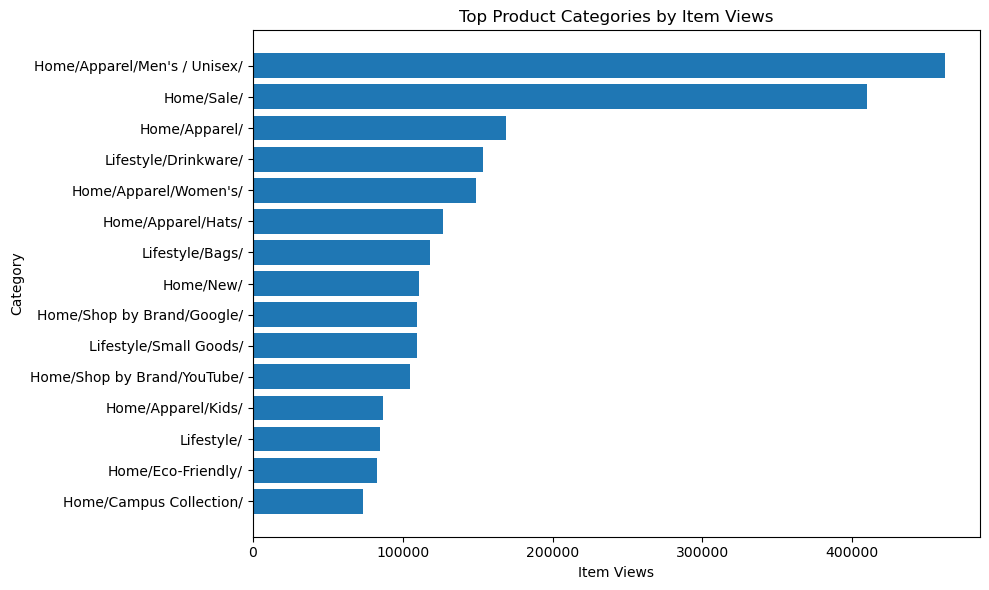

In [18]:

top_categories = category_perf_df.head(15).sort_values("item_views", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["item_category"], top_categories["item_views"])
plt.title("Top Product Categories by Item Views")
plt.xlabel("Item Views")
plt.ylabel("Category")
plt.tight_layout()
plt.show()



## Item-Level Notes

Write notes here:

- Which product categories drive the most views?
- Are there categories with high views but weak purchase conversion?
- Are item price and quantity reliable enough for category revenue analysis?



# 8. Basic Funnel Sanity Check

This is not the final funnel analysis. This quick check confirms that the key funnel events are present and usable.


In [19]:

basic_funnel_sql = f'''
SELECT
  event_name,
  COUNT(*) AS event_count,
  COUNT(DISTINCT user_pseudo_id) AS unique_users
FROM {EVENTS_TABLE}
WHERE event_name IN ('session_start', 'view_item', 'add_to_cart', 'begin_checkout', 'purchase')
GROUP BY event_name
ORDER BY
  CASE event_name
    WHEN 'session_start' THEN 1
    WHEN 'view_item' THEN 2
    WHEN 'add_to_cart' THEN 3
    WHEN 'begin_checkout' THEN 4
    WHEN 'purchase' THEN 5
    ELSE 99
  END
'''

basic_funnel_df = query_to_df(basic_funnel_sql)
basic_funnel_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_name,event_count,unique_users
0,session_start,354970,267116
1,view_item,386068,61252
2,add_to_cart,58543,12545
3,begin_checkout,38757,9715
4,purchase,5692,4419


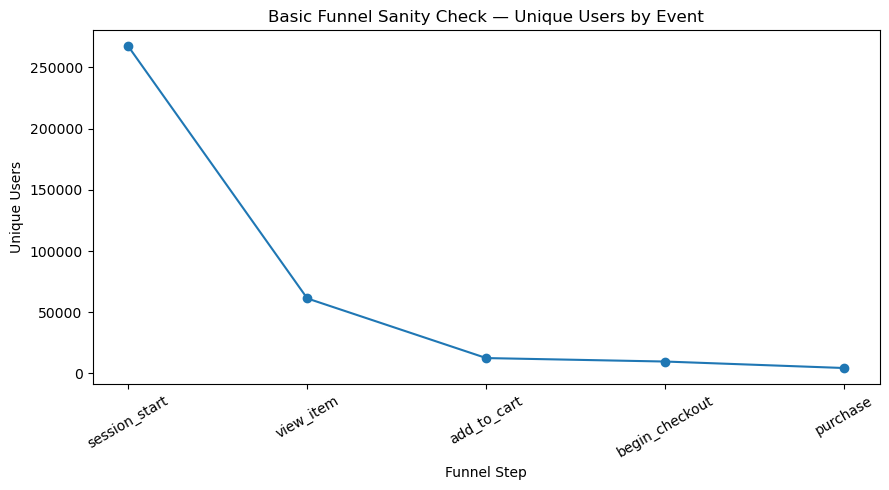

In [20]:

plt.figure(figsize=(9, 5))
plt.plot(basic_funnel_df["event_name"], basic_funnel_df["unique_users"], marker="o")
plt.title("Basic Funnel Sanity Check — Unique Users by Event")
plt.xlabel("Funnel Step")
plt.ylabel("Unique Users")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



## Basic Funnel Notes

Write notes here:

- Where does the largest drop-off appear at a high level?
- Which funnel step should be investigated more deeply later?
- Why is this only a sanity check and not the final funnel?



# 9. Null and Placeholder Value Checks

This identifies fields that need cleaning before building reusable SQL views.


In [21]:

null_placeholder_sql = f'''
SELECT
  COUNT(*) AS total_events,

  COUNTIF(user_pseudo_id IS NULL) AS missing_user_pseudo_id,

  COUNTIF(device.category IS NULL OR device.category = '') AS missing_device_category,
  COUNTIF(traffic_source.source IS NULL OR traffic_source.source = '' OR traffic_source.source = '(not set)') AS missing_or_placeholder_traffic_source,
  COUNTIF(traffic_source.medium IS NULL OR traffic_source.medium = '' OR traffic_source.medium = '(not set)') AS missing_or_placeholder_traffic_medium,
  COUNTIF(geo.country IS NULL OR geo.country = '') AS missing_country,

  COUNTIF(event_name = 'purchase' AND ecommerce.transaction_id IS NULL) AS purchase_missing_transaction_id,
  COUNTIF(event_name = 'purchase' AND ecommerce.purchase_revenue IS NULL) AS purchase_missing_revenue
FROM {EVENTS_TABLE}
'''

null_placeholder_df = query_to_df(null_placeholder_sql)
null_placeholder_df


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_events,missing_user_pseudo_id,missing_device_category,missing_or_placeholder_traffic_source,missing_or_placeholder_traffic_medium,missing_country,purchase_missing_transaction_id,purchase_missing_revenue
0,4295584,0,0,0,0,0,23,450


In [22]:

# Convert counts into percentages for easier reading
null_summary = null_placeholder_df.T.reset_index()
null_summary.columns = ["check_name", "count"]

total_events = int(null_placeholder_df["total_events"].iloc[0])
null_summary["pct_of_total_events"] = np.where(
    null_summary["check_name"] == "total_events",
    100,
    round(null_summary["count"] / total_events * 100, 2)
)

null_summary


,check_name,count,pct_of_total_events
0,total_events,4295584,100.00
1,missing_user_pseudo_id,0,0.00
2,missing_device_category,0,0.00
3,missing_or_placeholder_traffic_source,0,0.00
4,missing_or_placeholder_traffic_medium,0,0.00
5,missing_country,0,0.00
6,purchase_missing_transaction_id,23,0.00
7,purchase_missing_revenue,450,0.01



## Data Cleaning Decisions

Document your cleaning assumptions here.

Example:

- Treat missing or blank traffic source values as `unknown`.
- Treat missing device category values as `unknown`.
- Use `ecommerce.purchase_revenue` for transaction-level revenue.
- Use `item.price * item.quantity` only for item-level estimated revenue.
- Build a session key using `user_pseudo_id` and `ga_session_id`.
- Exclude records without `user_pseudo_id` from user-level modeling.



# 10. Final Data Quality Summary

Complete this section after running all cells.

## Key Findings

1. 
2. 
3. 

## Data Quality Issues

1. 
2. 
3. 

## Assumptions for Next Modules

1. 
2. 
3. 

## Next Step

Build the BigQuery SQL analytics layer:

- `01_stg_events.sql`
- `02_stg_items.sql`
- `03_int_sessions.sql`
- `04_mart_product_kpis.sql`
